In [486]:
import pandas as pd
import numpy as np
from pathlib import Path

# Cleaned dataset find karna
data_files = list(Path("../data").glob("*clean*.csv"))

print("Files found:", data_files)

# Cleaned dataset load karna
df = pd.read_csv(data_files[0])

print("Dataset shape:", df.shape)
df.head()

Files found: [WindowsPath('../data/cleaned_telco_customer_churn.csv')]
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [487]:
# Check columns and data types
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [488]:
# Feature 1: Average monthly spending

df["AvgMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

# Check the new feature
df[["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]].head(10)

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000
5,8,99.65,820.50,102.562500
6,22,89.10,1949.40,88.609091
7,10,29.75,301.90,30.190000
8,28,104.80,3046.05,108.787500
9,62,56.15,3487.95,56.257258


In [489]:
# Feature 2: Difference between average historical spending
# and current monthly charges

df["ChargeDifference"] = (
    df["AvgMonthlySpend"] - df["MonthlyCharges"]
)

# Check the new feature
df[
    [
        "MonthlyCharges",
        "AvgMonthlySpend",
        "ChargeDifference"
    ]
].head(10)

,MonthlyCharges,AvgMonthlySpend,ChargeDifference
0,29.85,29.850000,0.000000
1,56.95,55.573529,-1.376471
2,53.85,54.075000,0.225000
3,42.30,40.905556,-1.394444
4,70.70,75.825000,5.125000
5,99.65,102.562500,2.912500
6,89.10,88.609091,-0.490909
7,29.75,30.190000,0.440000
8,104.80,108.787500,3.987500
9,56.15,56.257258,0.107258


In [490]:
# Feature 3: Customer tenure groups

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 36, 60, float("inf")],
    labels=["New", "Medium", "Long-term", "Very Long-term"]
)

# Check the new feature
df[["tenure", "TenureGroup"]].head(15)

,tenure,TenureGroup
0,1,New
1,34,Medium
2,2,New
3,45,Long-term
4,2,New
5,8,New
6,22,Medium
7,10,New
8,28,Medium
9,62,Very Long-term


In [491]:
# Feature 4: Number of additional services used by customer

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (
    df[service_columns]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)

# Check the new feature
df[service_columns + ["ServiceCount"]].head(10)

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,ServiceCount
0,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,No,No,2
2,Yes,Yes,No,No,No,No,2
3,Yes,No,Yes,Yes,No,No,3
4,No,No,No,No,No,No,0
5,No,No,Yes,No,Yes,Yes,3
6,No,Yes,No,No,Yes,No,2
7,Yes,No,No,No,No,No,1
8,No,No,Yes,Yes,Yes,Yes,4
9,Yes,Yes,No,No,No,No,2


In [492]:
print("Number of columns:", df.shape[1])

print("\nAll columns:")
print(df.columns.tolist())

Number of columns: 25

All columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgMonthlySpend', 'ChargeDifference', 'TenureGroup', 'ServiceCount']


In [493]:
# Separate target variable
y = df["Churn"]

# Remove customer ID and target from features
X = df.drop(columns=["customerID", "Churn"])

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (7043, 23)
Target shape: (7043,)

Target values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [494]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training data: (5634, 23)
Testing data: (1409, 23)

Training target:
Churn
No     4139
Yes    1495
Name: count, dtype: int64

Testing target:
Churn
No     1035
Yes     374
Name: count, dtype: int64


In [495]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["str"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'ChargeDifference', 'ServiceCount']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [496]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [497]:
# Fit the preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the same preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5634, 48)
Processed testing data shape: (1409, 48)


In [498]:
# Convert target variable to 0 and 1

y_train_encoded = y_train.map({"No": 0, "Yes": 1})
y_test_encoded = y_test.map({"No": 0, "Yes": 1})

print("Training target:")
print(y_train_encoded.value_counts())

print("\nTesting target:")
print(y_test_encoded.value_counts())

Training target:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target:
Churn
0    1035
1     374
Name: count, dtype: int64


In [499]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train_encoded)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\Brahamdeo Chaudhary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [500]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing with scaling for numerical features
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit only on training data
X_train_processed = preprocessor_scaled.fit_transform(X_train)

# Apply same transformation to test data
X_test_processed = preprocessor_scaled.transform(X_test)

print("Scaled training data shape:", X_train_processed.shape)
print("Scaled testing data shape:", X_test_processed.shape)

Scaled training data shape: (5634, 48)
Scaled testing data shape: (1409, 48)


In [501]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train_encoded)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [502]:
# Make predictions on test data
y_pred_logistic = logistic_model.predict(X_test_processed)

print("First 20 predictions:")
print(y_pred_logistic[:20])

First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [503]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_encoded, y_pred_logistic)
recall = recall_score(y_test_encoded, y_pred_logistic)
f1 = f1_score(y_test_encoded, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Logistic Regression Results
---------------------------
Precision: 0.6604
Recall:    0.5668
F1-score:  0.6101


In [504]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model
random_forest_model.fit(
    X_train_processed,
    y_train_encoded
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [505]:
# Make predictions using Random Forest
y_pred_rf = random_forest_model.predict(X_test_processed)

# Calculate metrics
precision_rf = precision_score(y_test_encoded, y_pred_rf)
recall_rf = recall_score(y_test_encoded, y_pred_rf)
f1_rf = f1_score(y_test_encoded, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")

Random Forest Results
---------------------
Precision: 0.5605
Recall:    0.6444
F1-score:  0.5995


In [506]:
from xgboost import XGBClassifier

In [507]:
from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_model.fit(X_train_processed, y_train_encoded)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [508]:
# Make predictions using XGBoost
y_pred_xgb = xgb_model.predict(X_test_processed)

# Calculate metrics
precision_xgb = precision_score(y_test_encoded, y_pred_xgb)
recall_xgb = recall_score(y_test_encoded, y_pred_xgb)
f1_xgb = f1_score(y_test_encoded, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-score:  {f1_xgb:.4f}")

XGBoost Results
----------------
Precision: 0.6414
Recall:    0.4973
F1-score:  0.5602


In [509]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [510]:
# Get feature names after preprocessing

feature_names = preprocessor_scaled.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("\nFirst 20 feature names:")
print(feature_names[:20])

Number of feature names: 48

First 20 feature names:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__AvgMonthlySpend' 'num__ChargeDifference'
 'num__ServiceCount' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic']


In [511]:
# Create SHAP explainer for Logistic Regression

explainer = shap.LinearExplainer(
    logistic_model,
    X_train_processed
)

# Calculate SHAP values for test data
shap_values = explainer(X_test_processed)

print("SHAP values calculated successfully!")
print("SHAP values shape:", shap_values.values.shape)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


SHAP values calculated successfully!
SHAP values shape: (1409, 48)


In [512]:
# Calculate average absolute SHAP importance

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(shap_values.values).mean(axis=0)
})

# Sort from most important to least important
shap_importance = shap_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top 15 features
shap_importance.head(15)

,Feature,Importance
1,num__tenure,1.112609
3,num__TotalCharges,0.428053
19,cat__InternetService_Fiber optic,0.347694
2,num__MonthlyCharges,0.324706
4,num__AvgMonthlySpend,0.320719
18,cat__InternetService_DSL,0.301603
39,cat__Contract_Month-to-month,0.287603
41,cat__Contract_Two year,0.265426
6,num__ServiceCount,0.193382
42,cat__PaperlessBilling_No,0.172664


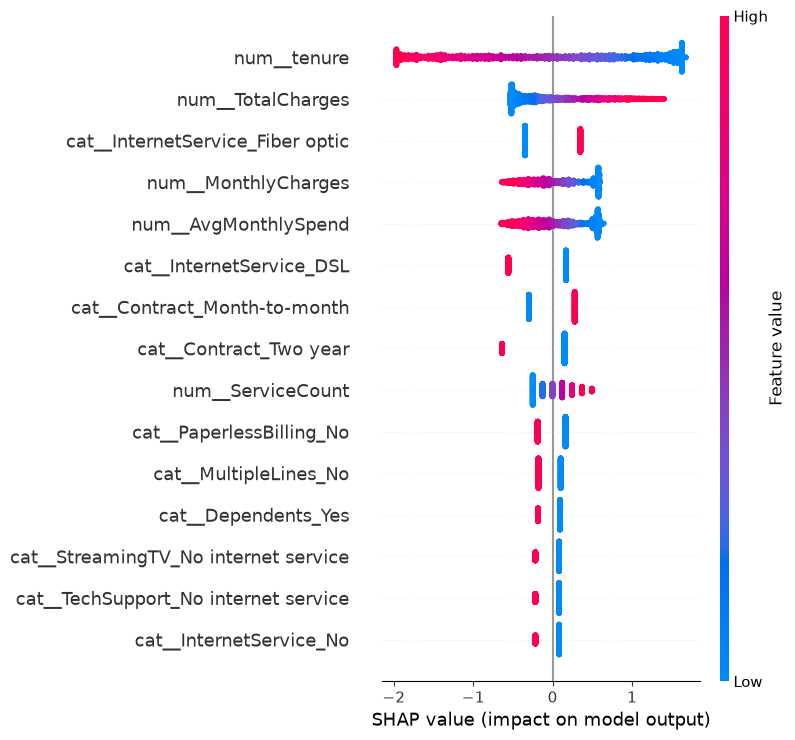

In [513]:
# SHAP summary plot

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    max_display=15
)